## **Problem Description**
- A streaming platform [**movielens.org**](https://movielens.org) are having a problem with its user retention.
- In 3 months, the user retention rate dropped almost 15% which really affects movielens revenues.
- After doing an urgent user research, movielens teams found that **users find it difficult to browse movie** in movielens which has nearly ~7000 movies.

## **Business Objective**
Our business objective would be **increasing user retention to 15%** (assumed of course) in 3 months.

## **Solution**
- We can create a **movie recommendation** to help user browse the movie easily.
- Remove the users difficulty in using movielens platform.

Some recommendations approach:
1. **Non-personalized**: recommendation by popularity
2. **Personalized**: collaborative filtering

## **Data Description**
- The data is obtained from [Movielens Dataset](https://grouplens.org/datasets/movielens/)
- It contains ~100k ratings from 1000 users and 1700 movies.

There are two files that we use:
**The movie rating data**: `rating.csv`

<center>

|Features|Descriptions|Data Type|
|:--|:--|:--:|
|`userId`|The user ID|`int`|
|`movieId`|The movie ID|`int`|
|`rating`|Rating given from user to movie. Ranging from `0` to `5`|`float`|

**The movie metadata**: `movies.csv`

<center>

|Features|Descriptions|Data Type|
|:--|:--|:--:|
|`movieId`|The movie ID|`int`|
|`title`|The movie ID title|`str`|
|`genres`|The movie ID genres|`str`|

# **Import Libraries**

In [1]:
# import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# define a function to load the data
def load_data(fname:str) -> pd.DataFrame:
    """
    Loads the data from the given file name and returns a pandas DataFrame.
    
    Parameters:
    fname (str): The name of the file to load the data from.
    
    Returns:
    pd.DataFrame: A DataFrame containing the loaded data.
    """
    # read the data from the file
    df = pd.read_csv(fname)

    # print the original data shape
    print(f'Original data shape: {df.shape}')
    
    return df

In [3]:
# load the rating data
df_ratings = load_data('../data/raw/ratings.csv')
df_ratings.head()

Original data shape: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
# check information summary
df_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [5]:
# drop the timestamp column
df_dropped = df_ratings.drop(columns=['timestamp'])
df_dropped.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [6]:
# remove any duplicate data and keep the latest
total_duplicated = df_dropped.duplicated().sum()
print(f'Total duplicated data: {total_duplicated}')

# drop duplicates
rating_data = df_dropped.drop_duplicates(keep='last')
print(f'After dropping duplicates, data shape: {rating_data.shape}')

rating_data.head()

Total duplicated data: 0
After dropping duplicates, data shape: (100836, 3)


,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [7]:
# validate data
assert len(rating_data.columns) == 3, "Data should have 3 columns: userId, movieId, rating"
assert rating_data.columns.tolist() == ['userId', 'movieId', 'rating'], "Column names should be userId, movieId, rating"
assert len(rating_data) == len(df_ratings), "Data should have the same number of rows as the original data after dropping duplicates"

# **Non-Personalized Recommendation: Top N Movies Rating Approach**

In [8]:
# load movies data
df_movies = load_data('../data/raw/movies.csv')
df_movies.head()

Original data shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
# check duplicated data
total_duplicated_movies = df_movies.duplicated().sum()
print(f'Total duplicated data in movies: {total_duplicated_movies}')

# drop duplicates
movies_data = df_movies.drop_duplicates(keep='last')
print(f'After dropping duplicates, movies data shape: {movies_data.shape}')

Total duplicated data in movies: 0
After dropping duplicates, movies data shape: (9742, 3)


In [10]:
# agg avg rating and count of ratings for each movie
movie_ratings_data = rating_data.groupby('movieId').agg({
    'rating': ['mean', 'count']}).reset_index()

# set the column names
movie_ratings_data.columns = ['movieId', 'avg_rating', 'rating_count']

# get top 5 movies with the most rating count
top_5_rated_count = movie_ratings_data.sort_values(by=['rating_count'], ascending=[False]).head(5)

# sort by avg rating from the top 5 movies with the most rating count
top_5_movies = top_5_rated_count.sort_values(by='avg_rating', ascending=False).head(5)
top_5_movies

,movieId,avg_rating,rating_count
277,318,4.429022,317
257,296,4.197068,307
1938,2571,4.192446,278
314,356,4.164134,329
510,593,4.161290,279


In [11]:
# merge movie ratings data with movies data
top_5_movies = pd.merge(top_5_movies, movies_data, on='movieId', how='inner')
top_5_movies 

,movieId,avg_rating,rating_count,title,genres
0,318,4.429022,317,"Shawshank Redemption, The (1994)",Crime|Drama
1,296,4.197068,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,2571,4.192446,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
3,356,4.164134,329,Forrest Gump (1994),Comedy|Drama|Romance|War
4,593,4.161290,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller


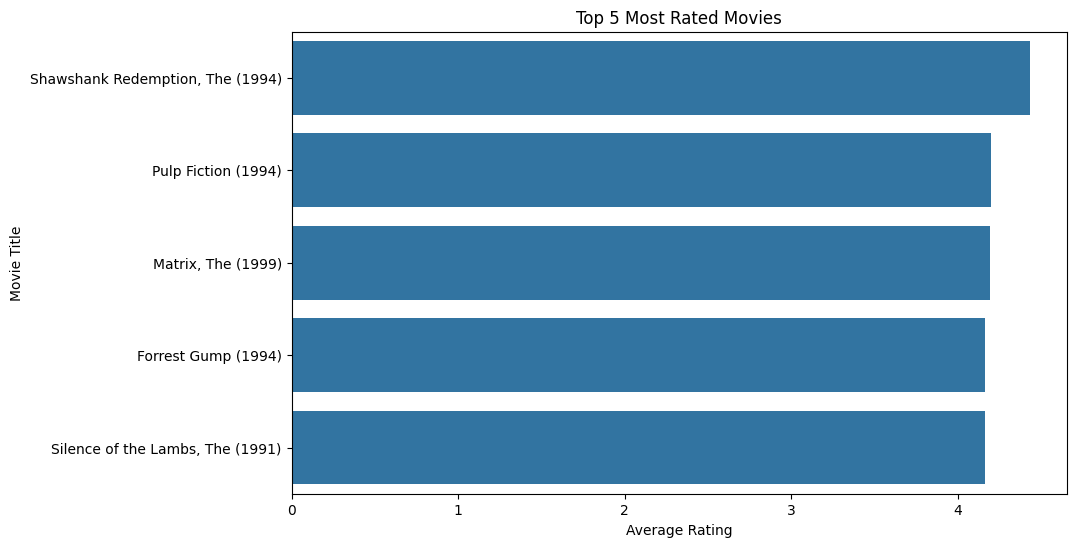

In [12]:
# visualize the top 5 movies
plt.figure(figsize=(10, 6))
sns.barplot(x='avg_rating', y='title', data=top_5_movies)
plt.title('Top 5 Most Rated Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.show()

# **Saved Rating Data**

In [13]:
# save rating data to processed data folder
rating_data.to_csv('../data/processed/rating_data.csv', index=False)